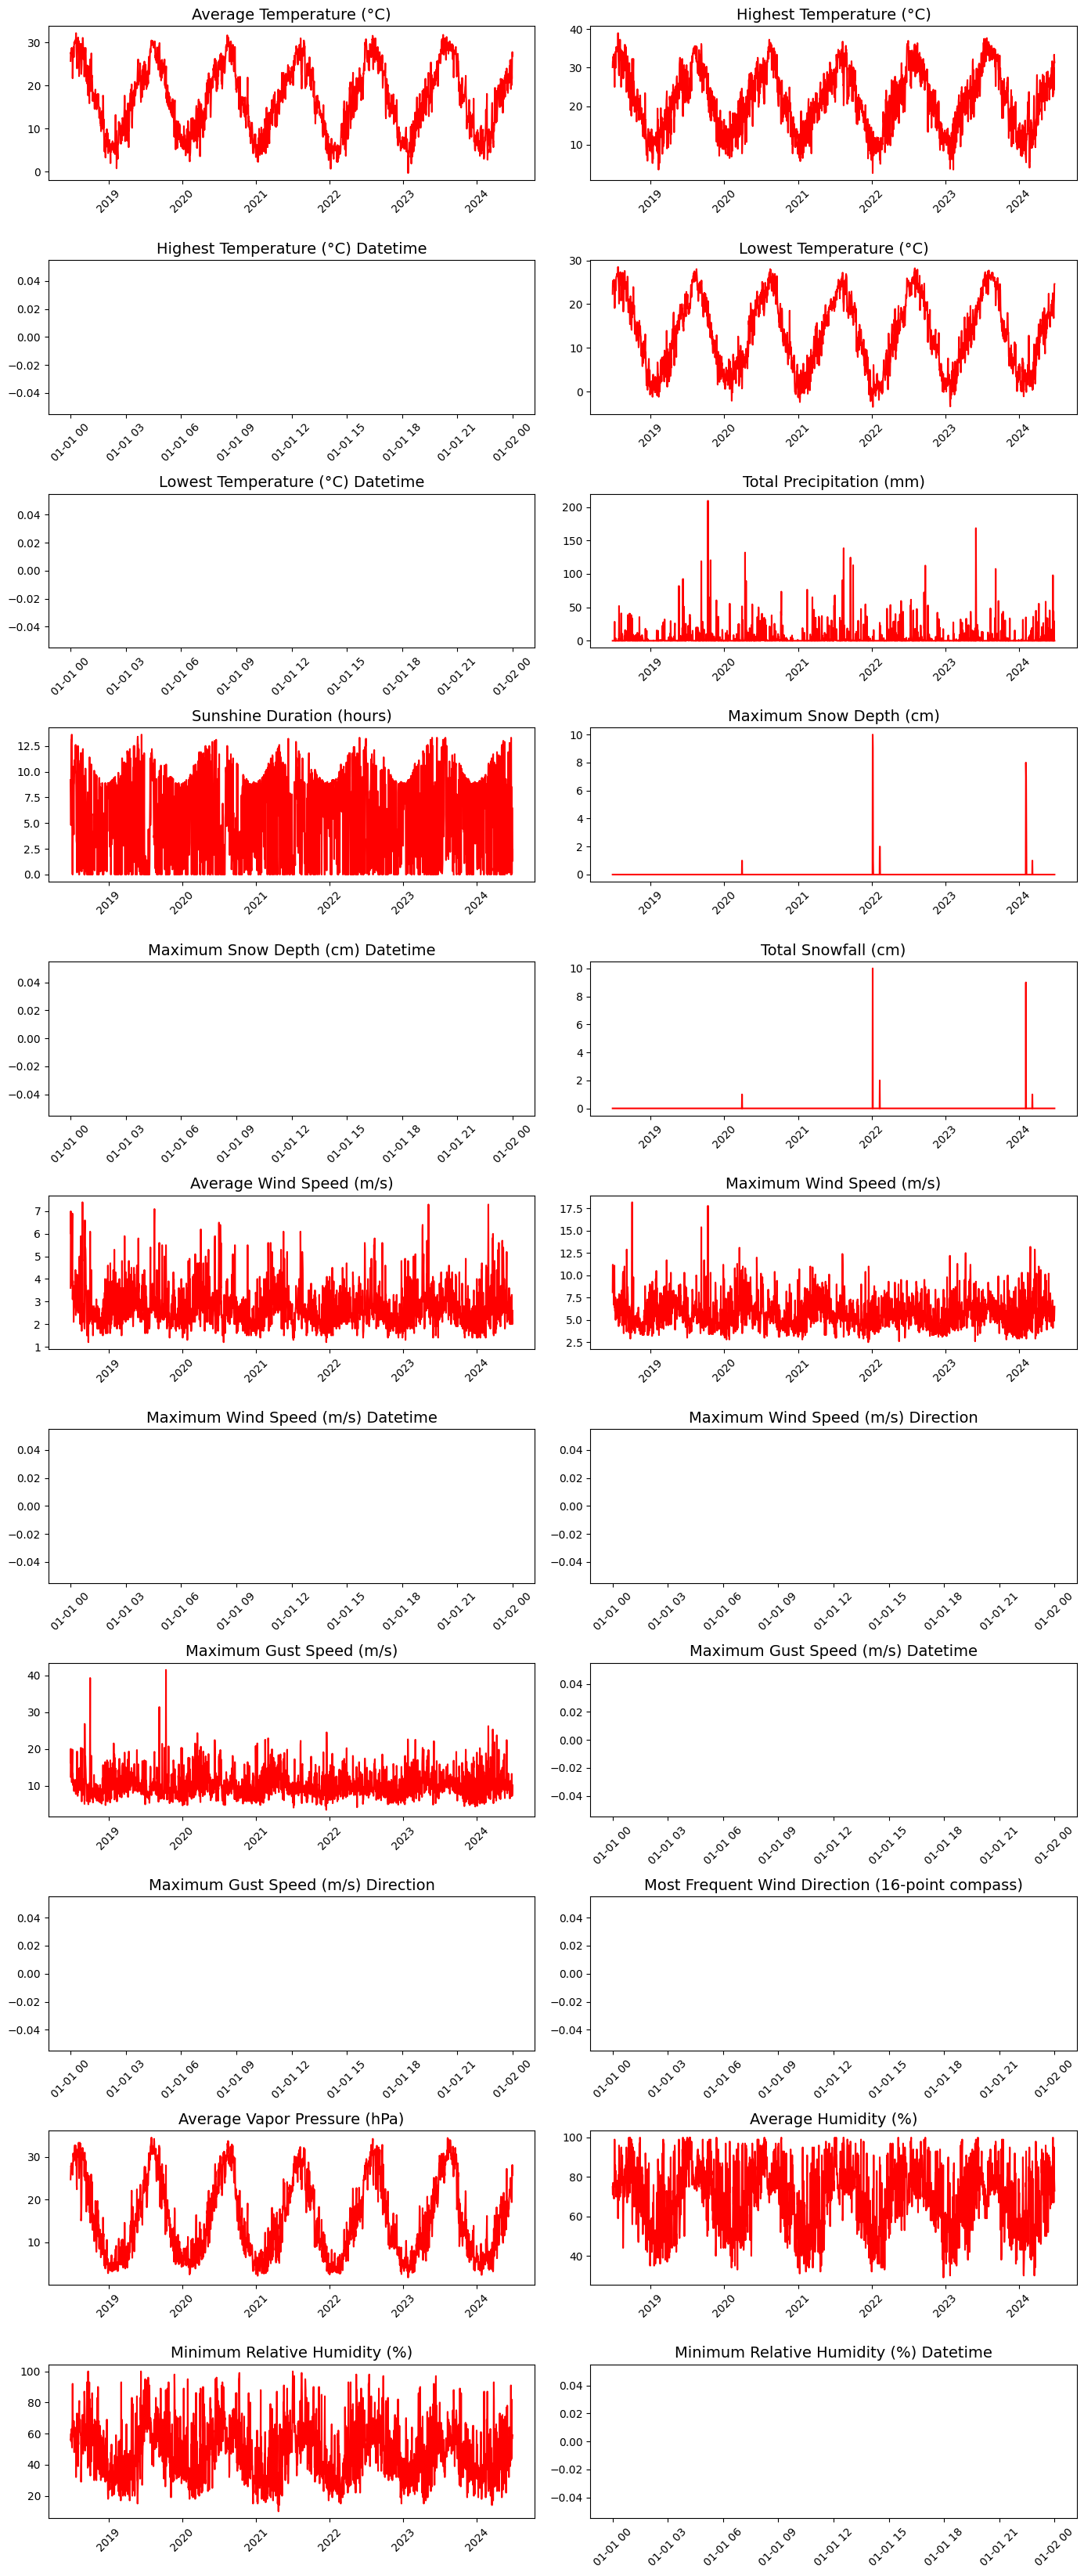

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from tqdm import tqdm_notebook
from itertools import product
import math

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

df = pd.read_csv('tokyo_weather.csv')
df.head()

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.sort_values("Date")
    x = df["Date"]
else:
    x = df.index

for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include="number").columns

n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(x, df[col], color="red")
    axes[i].set_title(col, fontsize=14)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
df.head()

,Date,Average Temperature (°C),Highest Temperature (°C),Highest Temperature (°C) Datetime,Lowest Temperature (°C),Lowest Temperature (°C) Datetime,Total Precipitation (mm),Sunshine Duration (hours),Maximum Snow Depth (cm),Maximum Snow Depth (cm) Datetime,...,Maximum Wind Speed (m/s) Datetime,Maximum Wind Speed (m/s) Direction,Maximum Gust Speed (m/s),Maximum Gust Speed (m/s) Datetime,Maximum Gust Speed (m/s) Direction,Most Frequent Wind Direction (16-point compass),Average Vapor Pressure (hPa),Average Humidity (%),Minimum Relative Humidity (%),Minimum Relative Humidity (%) Datetime
0,2018-06-26,25.7,30.1,NaN,22.3,NaN,0.0,9.2,0,NaN,...,NaN,NaN,12.4,NaN,NaN,NaN,24.7,75,56,NaN
1,2018-06-27,27.7,31.7,NaN,24.9,NaN,0.0,7.6,0,NaN,...,NaN,NaN,20.0,NaN,NaN,NaN,26.1,71,57,NaN
2,2018-06-28,27.4,31.9,NaN,25.2,NaN,0.0,4.8,0,NaN,...,NaN,NaN,16.1,NaN,NaN,NaN,27.9,77,60,NaN
3,2018-06-29,28.2,32.9,NaN,25.4,NaN,0.0,12.8,0,NaN,...,NaN,NaN,16.9,NaN,NaN,NaN,27.7,73,55,NaN
4,2018-06-30,28.6,32.7,NaN,25.2,NaN,0.0,13.1,0,NaN,...,NaN,NaN,15.5,NaN,NaN,NaN,28.5,74,57,NaN


In [37]:
from statsmodels.tsa.api import VAR
import pandas as pd
import numpy as np

# -----------------------------
# Settings
# -----------------------------
target_col = "Highest Temperature (°C)"
forecast_steps = 15

train_df = df[:-forecast_steps].copy()
test_df = df[-forecast_steps:].copy()

# -----------------------------
# Predictor variables
# -----------------------------
pred_list = best_useful_predictors["Predictor / causing variable (X)"].tolist()

# keep only first 5 useful predictors to reduce overfitting
pred_list = pred_list[:5]

# make sure target is included
var_cols = [target_col] + [col for col in pred_list if col != target_col]

train_X = train_df[var_cols].copy()
test_X = test_df[var_cols].copy()

# convert to numeric
for col in var_cols:
    train_X[col] = pd.to_numeric(train_X[col], errors="coerce")
    test_X[col] = pd.to_numeric(test_X[col], errors="coerce")

# remove missing rows
train_X = train_X.dropna()
test_X = test_X.dropna()

# -----------------------------
# Clean column names for VAR
# -----------------------------
original_names = train_X.columns.tolist()

train_X.columns = [f"x{i}" for i in range(train_X.shape[1])]
test_X.columns = train_X.columns

name_map = dict(zip(train_X.columns, original_names))

target_clean = [k for k, v in name_map.items() if v == target_col][0]

# -----------------------------
# Difference data
# -----------------------------
train_var = train_X.diff().dropna()

# -----------------------------
# Fit VAR with lag selection
# -----------------------------
var_model = VAR(train_var)

lag_results = var_model.select_order(maxlags=6)
print(lag_results.summary())

best_lag = lag_results.aic

if best_lag is None or best_lag < 1:
    best_lag = 1

print("Chosen lag:", best_lag)

fitted_model = var_model.fit(best_lag)

print(fitted_model.summary())

# -----------------------------
# Forecast differenced values
# -----------------------------
forecast_diff = fitted_model.forecast(
    train_var.values[-best_lag:],
    steps=len(test_X)
)

forecast_diff = pd.DataFrame(
    forecast_diff,
    columns=train_X.columns,
    index=test_X.index
)

# -----------------------------
# Convert differences back to original temperature scale
# -----------------------------
last_train_values = train_X.iloc[-1]

forecast_levels = forecast_diff.cumsum() + last_train_values.values

forecast_levels = pd.DataFrame(
    forecast_levels,
    columns=train_X.columns,
    index=test_X.index
)

# -----------------------------
# Actual vs predicted highest temperature
# -----------------------------
comparison_table = pd.DataFrame({
    "Actual Highest Temp": test_X[target_clean].values,
    "Predicted Highest Temp": forecast_levels[target_clean].values
}, index=test_X.index)

comparison_table["Error"] = (
    comparison_table["Actual Highest Temp"] -
    comparison_table["Predicted Highest Temp"]
)

comparison_table["Absolute Error"] = comparison_table["Error"].abs()

comparison_table["Absolute Percentage Error"] = (
    comparison_table["Absolute Error"] /
    comparison_table["Actual Highest Temp"].abs()
) * 100

display(comparison_table)

# -----------------------------
# Accuracy
# -----------------------------
mae = comparison_table["Absolute Error"].mean()
mape = comparison_table["Absolute Percentage Error"].mean()

print("MAE for Highest Temperature:", mae)
print("MAPE for Highest Temperature:", mape, "%")

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       12.32       12.33   2.234e+05       12.32
1       11.26       11.37   7.779e+04       11.30
2       10.67       10.88   4.315e+04       10.75
3       10.43       10.73   3.391e+04       10.54
4       10.28       10.67   2.905e+04       10.42
5       10.17      10.66*   2.606e+04       10.35
6      10.11*       10.69  2.447e+04*      10.32*
-------------------------------------------------
Chosen lag: 6
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 01, May, 2026
Time:                     17:23:33
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    10.6865
Nobs:                     2171.00    HQIC:                   10.3179
Log likelihood:          -29230.5    FPE:             

C:\Users\GGPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


,Actual Highest Temp,Predicted Highest Temp,Error,Absolute Error,Absolute Percentage Error
2178,30.1,28.593301,1.506699,1.506699,5.005645
2179,25.4,27.661756,-2.261756,2.261756,8.904550
2180,31.7,27.436797,4.263203,4.263203,13.448588
2181,29.9,27.274432,2.625568,2.625568,8.781165
2182,28.7,27.381686,1.318314,1.318314,4.593428
2183,30.5,27.286428,3.213572,3.213572,10.536300
2184,22.5,27.509894,-5.009894,5.009894,22.266196
2185,29.5,27.556313,1.943687,1.943687,6.588769
2186,28.4,27.480814,0.919186,0.919186,3.236569
2187,23.3,27.465540,-4.165540,4.165540,17.877853


MAE for Highest Temperature: 3.153084884041131
MAPE for Highest Temperature: 11.154033828621136 %
